In [ ]:
import gymnasium as gym
import numpy as np
from gymnasium import spaces
import math


class BatteryEnv(gym.Env):

    def __init__(
            self,
            n_hours=24,
            alpha=0.5,
            beta=0.5,
            lambda_unmet=10,
            lambda_curt=5,
            lambda_low_soc=10,        # Penalty weight for low SOC
            soc_threshold=0.2,        # SOC fraction below which penalty kicks in

            # Battery parameters
            max_soc=50.00,
            max_charge=30.00,
            max_discharge=30.00
    ):
        super().__init__()
        self.n_hours = int(n_hours)
        self.a = float(alpha)
        self.b = float(beta)
        self.lambda_unmet = float(lambda_unmet)
        self.lambda_curt = float(lambda_curt)
        self.lambda_low_soc = float(lambda_low_soc)
        self.soc_threshold = float(soc_threshold)
        self.max_soc = float(max_soc)
        self.max_charge = float(max_charge)
        self.max_discharge = float(max_discharge)

        # Action: 8 continuous values in [0, 1]
        # [U11, U12, U21, U22, U1B, U2B, UB1, UB2]
        self.action_space = spaces.Box(
            low=np.zeros(8, dtype=np.float32),
            high=np.ones(8, dtype=np.float32),
            dtype=np.float32,
        )

        # Observation: [t_norm, solar, wind, demand_1, demand_2, soc]
        self.observation_space = spaces.Box(
            low=np.zeros(6, dtype=np.float32),
            high=np.array([1.0, 200.0, 200.0, 30.0, 30.0, float(max_soc)], dtype=np.float32),
            dtype=np.float32,
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t = 0

        rng = self.np_random
        T = range(self.n_hours)

        demand_scale, solar, wind = self.generate_energy_profiles(rng, T)
        demand_1, demand_2 = self.generate_demands(rng, T, demand_scale)

        # Random initial SOC between 20% and 80% of max
        initial_soc = rng.uniform(0.2 * self.max_soc, 0.8 * self.max_soc)

        solar = np.clip(solar, 0.0, None)
        wind = np.clip(wind, 0.0, None)
        demand_1 = np.clip(demand_1, 0.0, None)
        demand_2 = np.clip(demand_2, 0.0, None)

        self.solar = solar
        self.wind = wind
        self.demand_1 = demand_1
        self.demand_2 = demand_2
        self.soc = initial_soc

        t_norm = 0.0
        obs = np.array([
            t_norm, self.solar[0], self.wind[0],
            self.demand_1[0], self.demand_2[0], self.soc
        ], dtype=np.float32)
        return obs, {}

    def step(self, action):
        # Current state
        available_solar = float(self.solar[self.t])
        available_wind = float(self.wind[self.t])
        demand_1 = float(self.demand_1[self.t])
        demand_2 = float(self.demand_2[self.t])
        soc = float(self.soc)

        # Parse and clip action
        U11, U12, U21, U22, U1B, U2B, UB1, UB2 = [
            float(x) for x in np.clip(action, 0.0, 1.0)
        ]

        # --- Raw energy allocation (before battery constraints) ---
        # Solar allocation (sequential: P1 first, then P2 from remainder, then battery)
        E11 = U11 * available_solar
        E12 = U12 * (available_solar - E11)
        E1B_raw = U1B * (available_solar - E11 - E12)

        # Wind allocation
        E21 = U21 * available_wind
        E22 = U22 * (available_wind - E21)
        E2B_raw = U2B * (available_wind - E21 - E22)

        # Battery discharge allocation
        B1_raw = UB1 * soc
        B2_raw = UB2 * (soc - B1_raw)

        # --- Netting: no simultaneous charge and discharge ---
        gross_charge = E1B_raw + E2B_raw
        gross_discharge = B1_raw + B2_raw

        if gross_charge >= gross_discharge:
            # Charge mode: apply charge, zero out discharge
            net_charge = gross_charge - gross_discharge
            net_charge = min(net_charge, self.max_charge, self.max_soc - soc)
            net_charge = max(net_charge, 0.0)

            # Scale E1B, E2B proportionally to match net_charge
            if gross_charge > 1e-8:
                charge_scale = net_charge / gross_charge
            else:
                charge_scale = 0.0

            E1B = E1B_raw * charge_scale
            E2B = E2B_raw * charge_scale
            B1 = 0.0
            B2 = 0.0

            actual_charge = net_charge
            actual_discharge = 0.0
        else:
            # Discharge mode: apply discharge, zero out charge
            net_discharge = gross_discharge - gross_charge
            net_discharge = min(net_discharge, self.max_discharge, soc)
            net_discharge = max(net_discharge, 0.0)

            # Scale B1, B2 proportionally to match net_discharge
            if gross_discharge > 1e-8:
                discharge_scale = net_discharge / gross_discharge
            else:
                discharge_scale = 0.0

            B1 = B1_raw * discharge_scale
            B2 = B2_raw * discharge_scale
            E1B = 0.0
            E2B = 0.0

            actual_charge = 0.0
            actual_discharge = net_discharge

        # --- SOC update ---
        self.soc = soc + actual_charge - actual_discharge

        # --- Production ---
        P1 = self.a * (E11 + E21 + B1)
        P2 = self.b * (E12 + E22 + B2)

        # --- Curtailment (energy not used and not stored) ---
        curt_solar = max(0.0, available_solar - (E11 + E12 + E1B))
        curt_wind = max(0.0, available_wind - (E21 + E22 + E2B))

        # --- Unmet demand ---
        unmet_1 = max(0.0, demand_1 - P1)
        unmet_2 = max(0.0, demand_2 - P2)

        # --- Low SOC penalty (soft, gradient-friendly) ---
        soc_threshold_abs = self.soc_threshold * self.max_soc
        if self.soc < soc_threshold_abs:
            low_soc_penalty = self.lambda_low_soc * (soc_threshold_abs - self.soc)
        else:
            low_soc_penalty = 0.0

        # --- Reward ---
        reward = (
            P1 + P2
            - self.lambda_unmet * (unmet_1 + unmet_2)
            - self.lambda_curt * (curt_solar + curt_wind)
            - low_soc_penalty
        )

        info = {
            "t": self.t,
            "solar": available_solar,
            "wind": available_wind,
            "demand_1": demand_1,
            "demand_2": demand_2,
            "E11": E11, "E12": E12,
            "E21": E21, "E22": E22,
            "E1B": E1B, "E2B": E2B,
            "B1": B1, "B2": B2,
            "P1": P1, "P2": P2,
            "soc": self.soc,
            "actual_charge": actual_charge,
            "actual_discharge": actual_discharge,
            "curt_solar": curt_solar,
            "curt_wind": curt_wind,
            "unmet_1": unmet_1,
            "unmet_2": unmet_2,
            "low_soc_penalty": low_soc_penalty,
        }

        # Advance time
        self.t += 1
        terminated = (self.t >= self.n_hours)
        truncated = False

        if terminated:
            obs = np.zeros(6, dtype=np.float32)
        else:
            t_norm = self.t / (self.n_hours - 1)
            obs = np.array([
                t_norm, self.solar[self.t], self.wind[self.t],
                self.demand_1[self.t], self.demand_2[self.t], self.soc  # Fixed: uses updated SOC
            ], dtype=np.float32)

        return obs, float(reward), terminated, truncated, info

    # def generate_demands(self, rng, T, demand_scale):
    #     demand_1 = np.array([5.0 + 1.0 * math.sin(2 * math.pi * t / self.n_hours) for t in T], dtype=np.float32)
    #     demand_2 = np.array([4.0 + 1.0 * math.cos(2 * math.pi * t / self.n_hours) for t in T], dtype=np.float32)
    #     demand_1 *= demand_scale * (1.0 + rng.normal(0.0, 0.02, size=self.n_hours)).astype(np.float32)
    #     demand_2 *= demand_scale * (1.0 + rng.normal(0.0, 0.02, size=self.n_hours)).astype(np.float32)
    #     return demand_1, demand_2

    # def generate_energy_profiles(self, rng, T):
    #     solar_peak = rng.uniform(40.0, 80.0)
    #     cloud_factor = rng.uniform(0.2, 1.0)
    #     wind_mean = rng.uniform(20.0, 50.0)
    #     wind_sigma = rng.uniform(2.0, 8.0)
    #     demand_scale = rng.uniform(0.85, 1.15)

    #     solar = np.zeros(self.n_hours, dtype=np.float32)
    #     for t in T:
    #         if 6 <= t < 18:
    #             solar[t] = solar_peak * (1.0 - abs(t - 12) / 6.0)
    #     solar *= cloud_factor
    #     solar *= (1.0 + rng.normal(0.0, 0.05, size=self.n_hours)).astype(np.float32)

    #     wind = (wind_mean + rng.normal(0.0, wind_sigma, size=self.n_hours)).astype(np.float32)
    #     return demand_scale, solar, wind

    def generate_energy_profiles(self, rng, T):
        # --- Solar ---
        solar_peak = rng.uniform(30.0, 60.0)
        cloud_factor = rng.uniform(0.3, 1.0)

        # Base shape: smooth bell curve centered at noon (more realistic than triangle)
        solar = np.zeros(self.n_hours, dtype=np.float32)
        for t in T:
            if 6 <= t <= 18:
                # Gaussian-like shape centered at hour 12
                solar[t] = solar_peak * math.exp(-0.5 * ((t - 12) / 2.5) ** 2)

        solar *= cloud_factor

        # Cloud events: random dips during sunny hours (partial cloud cover)
        for t in T:
            if 6 <= t <= 18 and rng.random() < 0.2:  # 20% chance per hour
                solar[t] *= rng.uniform(0.2, 0.7)

        # Small smooth noise
        solar *= (1.0 + rng.normal(0.0, 0.03, size=self.n_hours)).astype(np.float32)

        # --- Wind (autoregressive process for temporal structure) ---
        wind_mean = rng.uniform(15.0, 40.0)
        wind = np.zeros(self.n_hours, dtype=np.float32)
        wind[0] = wind_mean + rng.normal(0.0, 3.0)

        persistence = rng.uniform(0.7, 0.95)  # How correlated consecutive hours are
        innovation_std = rng.uniform(2.0, 6.0)

        for t in range(1, self.n_hours):
            # AR(1): wind tends to stay similar to previous hour
            wind[t] = (
                persistence * wind[t - 1]
                + (1 - persistence) * wind_mean
                + rng.normal(0.0, innovation_std)
            )

        # Occasional wind drought or gust event
        if rng.random() < 0.15:  # 15% chance of a calm period
            calm_start = rng.integers(0, self.n_hours - 4)
            calm_duration = rng.integers(3, min(8, self.n_hours - calm_start))
            wind[calm_start:calm_start + calm_duration] *= rng.uniform(0.1, 0.4)

        if rng.random() < 0.15:  # 15% chance of a gust period
            gust_start = rng.integers(0, self.n_hours - 3)
            gust_duration = rng.integers(2, min(6, self.n_hours - gust_start))
            wind[gust_start:gust_start + gust_duration] *= rng.uniform(1.5, 2.5)

        # --- Demand scale ---
        demand_scale = rng.uniform(0.85, 1.15)

        return demand_scale, solar.astype(np.float32), wind.astype(np.float32)


    def generate_demands(self, rng, T, demand_scale):
        # --- Demand 1 (Electrolyser): double peak, morning + evening ---
        demand_1 = np.zeros(self.n_hours, dtype=np.float32)
        for t in T:
            morning_peak = 8.0 * math.exp(-0.5 * ((t - 9) / 2.0) ** 2)
            evening_peak = 10.0 * math.exp(-0.5 * ((t - 19) / 2.0) ** 2)
            base_load = 3.0  # Minimum load even at night
            demand_1[t] = base_load + morning_peak + evening_peak

        # --- Demand 2 (ASU): shifted pattern, peaks in afternoon ---
        demand_2 = np.zeros(self.n_hours, dtype=np.float32)
        for t in T:
            afternoon_peak = 9.0 * math.exp(-0.5 * ((t - 14) / 2.5) ** 2)
            night_load = 2.0 * math.exp(-0.5 * ((t - 2) / 3.0) ** 2)
            base_load = 2.5
            demand_2[t] = base_load + afternoon_peak + night_load

        # Apply demand scale and per-timestep noise (5% noise, more realistic)
        demand_1 *= demand_scale * (1.0 + rng.normal(0.0, 0.05, size=self.n_hours)).astype(np.float32)
        demand_2 *= demand_scale * (1.0 + rng.normal(0.0, 0.05, size=self.n_hours)).astype(np.float32)

        # Occasional demand spike (e.g. process startup)
        if rng.random() < 0.2:
            spike_hour = rng.integers(0, self.n_hours)
            demand_1[spike_hour] *= rng.uniform(1.5, 2.5)

        if rng.random() < 0.2:
            spike_hour = rng.integers(0, self.n_hours)
            demand_2[spike_hour] *= rng.uniform(1.5, 2.5)

        return demand_1, demand_2

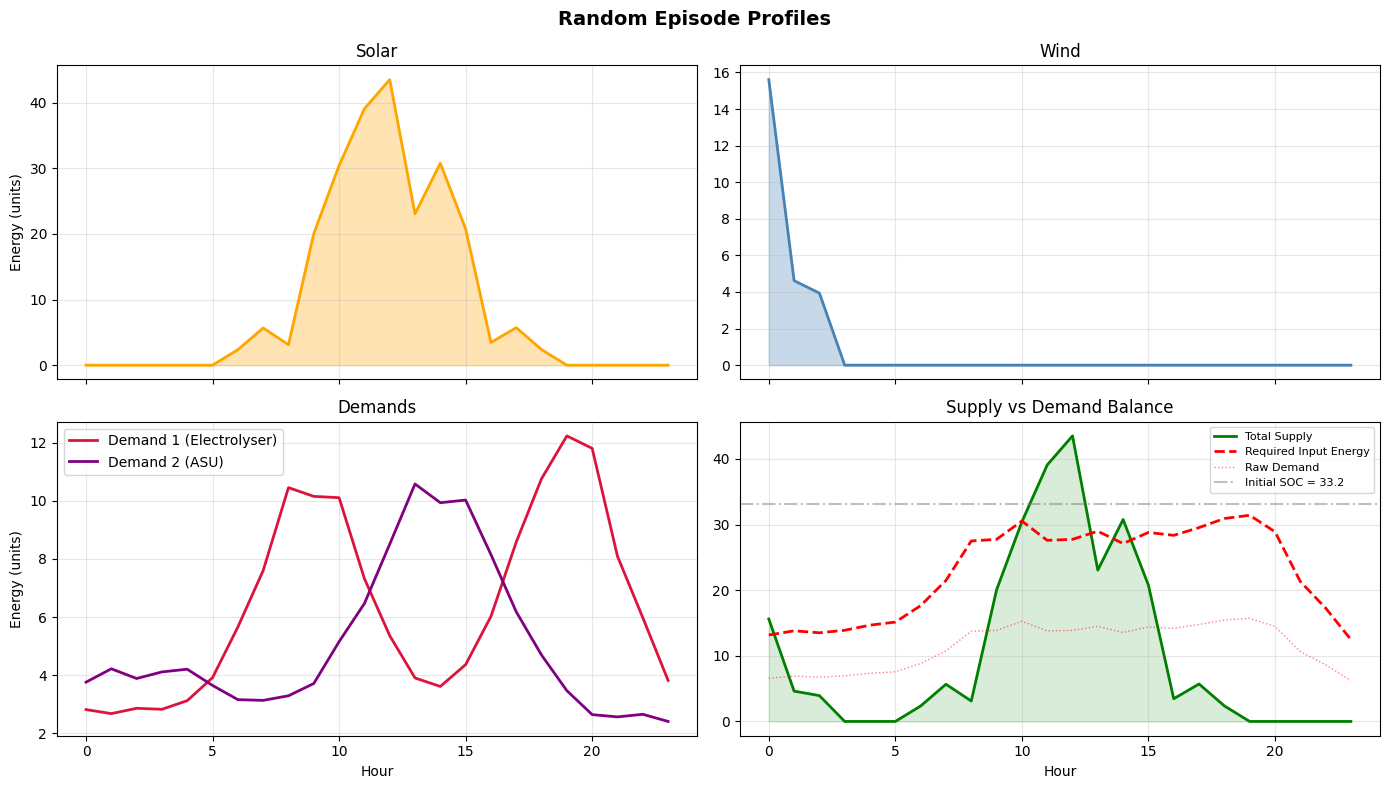

Solar peak: 43.5 | Wind avg: 1.0 | Initial SOC: 33.2
Demand 1 range: [2.7, 12.2]
Demand 2 range: [2.4, 10.6]
Hours where required input > supply: 20 / 24


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a fresh env and reset to generate random profiles
env = BatteryEnv()
obs, _ = env.reset()

hours = np.arange(env.n_hours)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
fig.suptitle("Random Episode Profiles", fontsize=14, fontweight="bold")

# --- Solar ---
axes[0, 0].fill_between(hours, env.solar, alpha=0.3, color="orange")
axes[0, 0].plot(hours, env.solar, color="orange", linewidth=2)
axes[0, 0].set_ylabel("Energy (units)")
axes[0, 0].set_title("Solar")
axes[0, 0].grid(True, alpha=0.3)

# --- Wind ---
axes[0, 1].fill_between(hours, env.wind, alpha=0.3, color="steelblue")
axes[0, 1].plot(hours, env.wind, color="steelblue", linewidth=2)
axes[0, 1].set_title("Wind")
axes[0, 1].grid(True, alpha=0.3)

# --- Demands ---
axes[1, 0].plot(hours, env.demand_1, color="crimson", linewidth=2, label="Demand 1 (Electrolyser)")
axes[1, 0].plot(hours, env.demand_2, color="purple", linewidth=2, label="Demand 2 (ASU)")
axes[1, 0].set_xlabel("Hour")
axes[1, 0].set_ylabel("Energy (units)")
axes[1, 0].set_title("Demands")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# --- Supply vs Total Demand ---
total_supply = env.solar + env.wind
total_demand_raw = env.demand_1 + env.demand_2
# Demand after efficiency: agent needs demand/efficiency worth of input energy
total_demand_input = env.demand_1 / env.a + env.demand_2 / env.b

axes[1, 1].fill_between(hours, total_supply, alpha=0.15, color="green")
axes[1, 1].plot(hours, total_supply, color="green", linewidth=2, label="Total Supply")
axes[1, 1].plot(hours, total_demand_input, color="red", linewidth=2, linestyle="--", label="Required Input Energy")
axes[1, 1].plot(hours, total_demand_raw, color="red", linewidth=1, linestyle=":", alpha=0.5, label="Raw Demand")
axes[1, 1].axhline(y=env.soc, color="gray", linestyle="-.", alpha=0.5, label=f"Initial SOC = {env.soc:.1f}")
axes[1, 1].set_xlabel("Hour")
axes[1, 1].set_title("Supply vs Demand Balance")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary stats
print(f"Solar peak: {env.solar.max():.1f} | Wind avg: {env.wind.mean():.1f} | Initial SOC: {env.soc:.1f}")
print(f"Demand 1 range: [{env.demand_1.min():.1f}, {env.demand_1.max():.1f}]")
print(f"Demand 2 range: [{env.demand_2.min():.1f}, {env.demand_2.max():.1f}]")
print(f"Hours where required input > supply: {np.sum(total_demand_input > total_supply)} / {env.n_hours}")

In [ ]:
from gymnasium.utils.env_checker import check_env

env = BatteryEnv()
check_env(env, skip_render_check=True)
print("Environment check passed!")

Environment check passed!


In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
from stable_baselines3.common.callbacks import EvalCallback, BaseCallback
import numpy as np
import matplotlib.pyplot as plt


# --- Custom callback to log reward components ---
class RewardComponentCallback(BaseCallback):
    def __init__(self, eval_env, eval_freq=5000, n_eval_episodes=10, verbose=0):
        super().__init__(verbose)
        self.eval_env = eval_env
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.results = {
            "timesteps": [],
            "mean_reward": [],
            "mean_unmet": [],
            "mean_curt": [],
            "mean_p1": [],
            "mean_p2": [],
            "mean_soc": [],
        }

    def _on_step(self):
        if self.n_calls % self.eval_freq == 0:
            all_rewards, all_unmet, all_curt, all_p1, all_p2, all_soc = [], [], [], [], [], []

            for _ in range(self.n_eval_episodes):
                obs, _ = self.eval_env.reset()
                ep_reward, ep_unmet, ep_curt, ep_p1, ep_p2, ep_soc = 0, 0, 0, 0, 0, 0
                done = False

                while not done:
                    action, _ = self.model.predict(obs, deterministic=True)
                    obs, reward, terminated, truncated, info = self.eval_env.step(action)
                    done = terminated or truncated

                    ep_reward += reward
                    ep_unmet += info["unmet_1"] + info["unmet_2"]
                    ep_curt += info["curt_solar"] + info["curt_wind"]
                    ep_p1 += info["P1"]
                    ep_p2 += info["P2"]
                    ep_soc += info["soc"]

                all_rewards.append(ep_reward)
                all_unmet.append(ep_unmet)
                all_curt.append(ep_curt)
                all_p1.append(ep_p1)
                all_p2.append(ep_p2)
                all_soc.append(ep_soc / 24)  # Average SOC per step

            self.results["timesteps"].append(self.n_calls)
            self.results["mean_reward"].append(np.mean(all_rewards))
            self.results["mean_unmet"].append(np.mean(all_unmet))
            self.results["mean_curt"].append(np.mean(all_curt))
            self.results["mean_p1"].append(np.mean(all_p1))
            self.results["mean_p2"].append(np.mean(all_p2))
            self.results["mean_soc"].append(np.mean(all_soc))

            if self.verbose:
                print(f"[{self.n_calls}] reward={np.mean(all_rewards):.1f} "
                      f"unmet={np.mean(all_unmet):.1f} curt={np.mean(all_curt):.1f}")

        return True


# --- Environment factory ---
def make_env(seed):
    def _init():
        env = BatteryEnv()
        env.reset(seed=seed)
        return env
    return _init


# --- Training setup ---
n_envs = 4  # Parallel environments for PPO
train_env = DummyVecEnv([make_env(seed=i) for i in range(n_envs)])
train_env = VecMonitor(train_env)

eval_env = BatteryEnv()  # Single env for evaluation

# --- PPO model ---
model = PPO(
    "MlpPolicy",
    train_env,
    learning_rate=3e-4,
    n_steps=1024,           # Steps per env before update
    batch_size=256,
    n_epochs=10,             # Passes over collected data per update
    gamma=0.99,              # Discount factor (high because future steps matter)
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,           # Entropy bonus for exploration
    verbose=0,
    policy_kwargs=dict(
        net_arch=dict(pi=[128, 128], vf=[128, 128])  # Separate policy/value networks
    ),
)

# --- Callbacks ---
component_cb = RewardComponentCallback(
    eval_env=eval_env,
    eval_freq=5000,
    n_eval_episodes=10,
    verbose=1,
)

# --- Train ---
total_timesteps = 300_000
model.learn(total_timesteps=total_timesteps, callback=component_cb)
model.save("ppo_p2x")

print("Training complete!")

[5000] reward=-3927.0 unmet=142.3 curt=532.8
[10000] reward=-1821.3 unmet=87.1 curt=244.8
[15000] reward=-852.5 unmet=77.5 curt=74.6
[20000] reward=-815.3 unmet=104.2 curt=23.7
[25000] reward=-637.9 unmet=100.4 curt=8.2
[30000] reward=-449.8 unmet=84.0 curt=3.1
[35000] reward=-419.3 unmet=82.6 curt=2.1
[40000] reward=-373.9 unmet=74.6 curt=1.2
[45000] reward=-305.2 unmet=72.3 curt=0.1
[50000] reward=-287.3 unmet=73.1 curt=1.3
[55000] reward=-422.3 unmet=81.4 curt=0.4
[60000] reward=-216.6 unmet=63.1 curt=0.4
[65000] reward=-461.4 unmet=83.3 curt=0.3
[70000] reward=-207.8 unmet=61.1 curt=0.1
[75000] reward=-404.5 unmet=75.7 curt=0.1
Training complete!


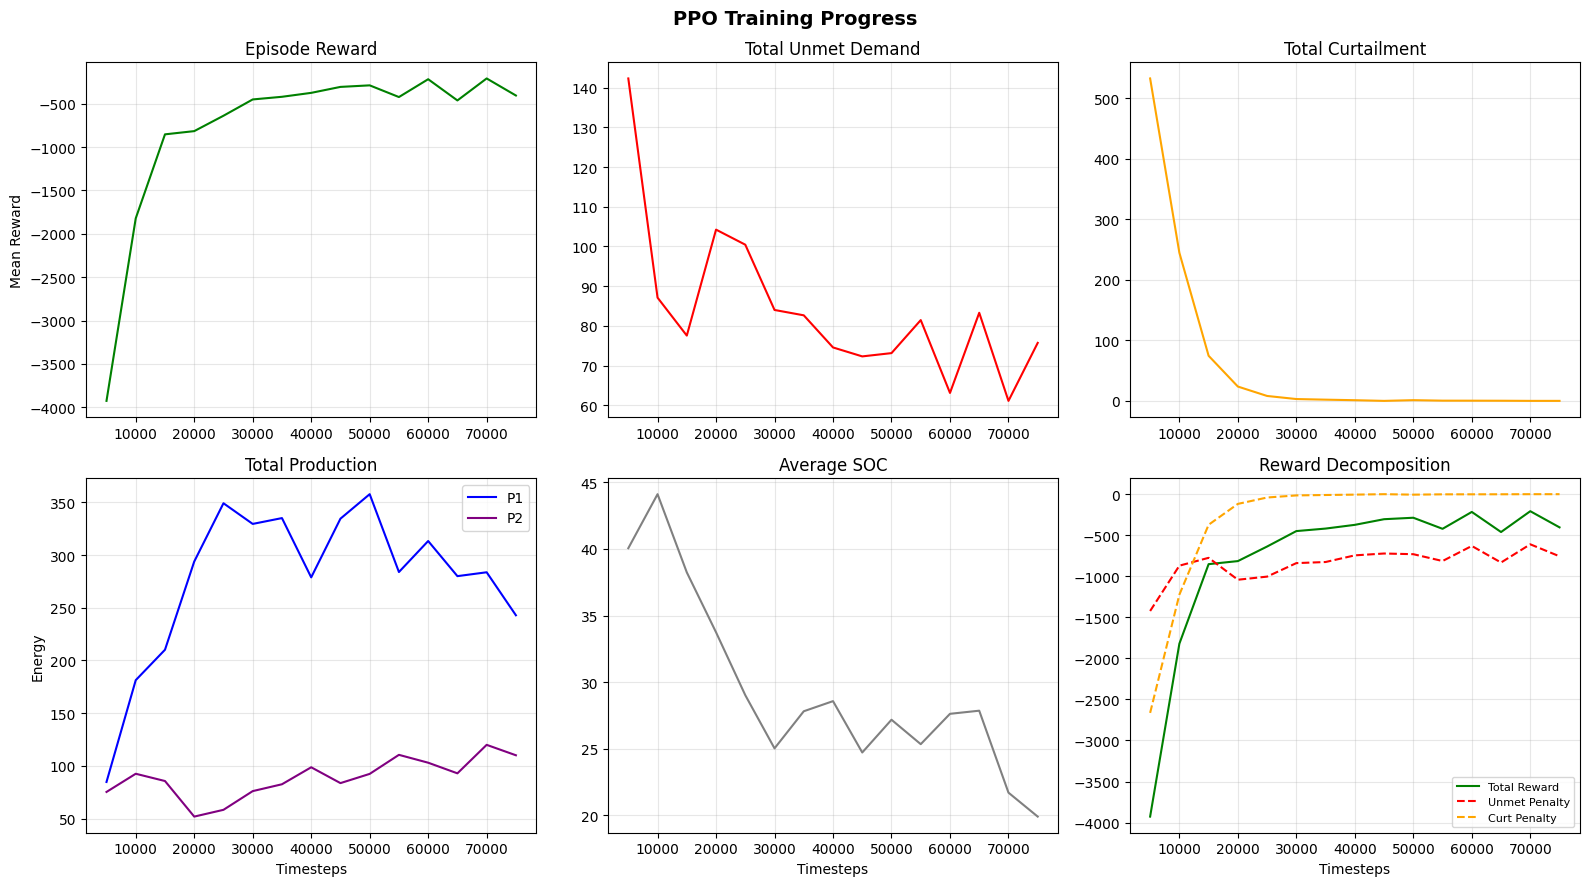

In [28]:
# --- Plot training progress ---
def plot_training_progress():
    res = component_cb.results

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle("PPO Training Progress", fontsize=14, fontweight="bold")

    axes[0, 0].plot(res["timesteps"], res["mean_reward"], color="green")
    axes[0, 0].set_title("Episode Reward")
    axes[0, 0].set_ylabel("Mean Reward")
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(res["timesteps"], res["mean_unmet"], color="red")
    axes[0, 1].set_title("Total Unmet Demand")
    axes[0, 1].grid(True, alpha=0.3)

    axes[0, 2].plot(res["timesteps"], res["mean_curt"], color="orange")
    axes[0, 2].set_title("Total Curtailment")
    axes[0, 2].grid(True, alpha=0.3)

    axes[1, 0].plot(res["timesteps"], res["mean_p1"], color="blue", label="P1")
    axes[1, 0].plot(res["timesteps"], res["mean_p2"], color="purple", label="P2")
    axes[1, 0].set_title("Total Production")
    axes[1, 0].set_xlabel("Timesteps")
    axes[1, 0].set_ylabel("Energy")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(res["timesteps"], res["mean_soc"], color="gray")
    axes[1, 1].set_title("Average SOC")
    axes[1, 1].set_xlabel("Timesteps")
    axes[1, 1].grid(True, alpha=0.3)

# Reward decomposition
    axes[1, 2].plot(res["timesteps"], res["mean_reward"], color="green", label="Total Reward")
    unmet_penalty = [-10 * u for u in res["mean_unmet"]]
    curt_penalty = [-5 * c for c in res["mean_curt"]]
    axes[1, 2].plot(res["timesteps"], unmet_penalty, color="red", linestyle="--", label="Unmet Penalty")
    axes[1, 2].plot(res["timesteps"], curt_penalty, color="orange", linestyle="--", label="Curt Penalty")
    axes[1, 2].set_title("Reward Decomposition")
    axes[1, 2].set_xlabel("Timesteps")
    axes[1, 2].legend(fontsize=8)
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_progress()

In [29]:
# --- Continue training for more steps ---
model.learn(total_timesteps=500_000, callback=component_cb, reset_num_timesteps=False)
model.save("ppo_p2x_extended")
print("Extended training complete!")

[80000] reward=-222.3 unmet=64.0 curt=0.1
[85000] reward=-162.8 unmet=56.8 curt=0.0
[90000] reward=-214.0 unmet=62.3 curt=0.0
[95000] reward=-108.3 unmet=52.6 curt=0.0
[100000] reward=51.4 unmet=42.7 curt=0.0
[105000] reward=-268.7 unmet=61.9 curt=0.0
[110000] reward=-294.6 unmet=66.2 curt=0.0
[115000] reward=-36.7 unmet=45.8 curt=0.0
[120000] reward=-2.4 unmet=43.0 curt=0.0
[125000] reward=-8.7 unmet=45.7 curt=0.0
[130000] reward=-129.8 unmet=52.9 curt=0.0
[135000] reward=-82.6 unmet=45.7 curt=0.0
[140000] reward=-51.5 unmet=47.7 curt=0.0
[145000] reward=-119.0 unmet=50.9 curt=0.0
[150000] reward=-32.3 unmet=46.3 curt=0.0
[155000] reward=37.8 unmet=42.1 curt=0.0
[160000] reward=-110.3 unmet=49.2 curt=0.0
[165000] reward=-3.7 unmet=45.0 curt=0.0
[170000] reward=80.2 unmet=35.8 curt=0.0
[175000] reward=75.5 unmet=36.6 curt=0.0
[180000] reward=72.8 unmet=35.1 curt=0.0
[185000] reward=-94.1 unmet=50.4 curt=0.0
[190000] reward=74.5 unmet=36.3 curt=0.0
[195000] reward=-253.8 unmet=63.2 curt

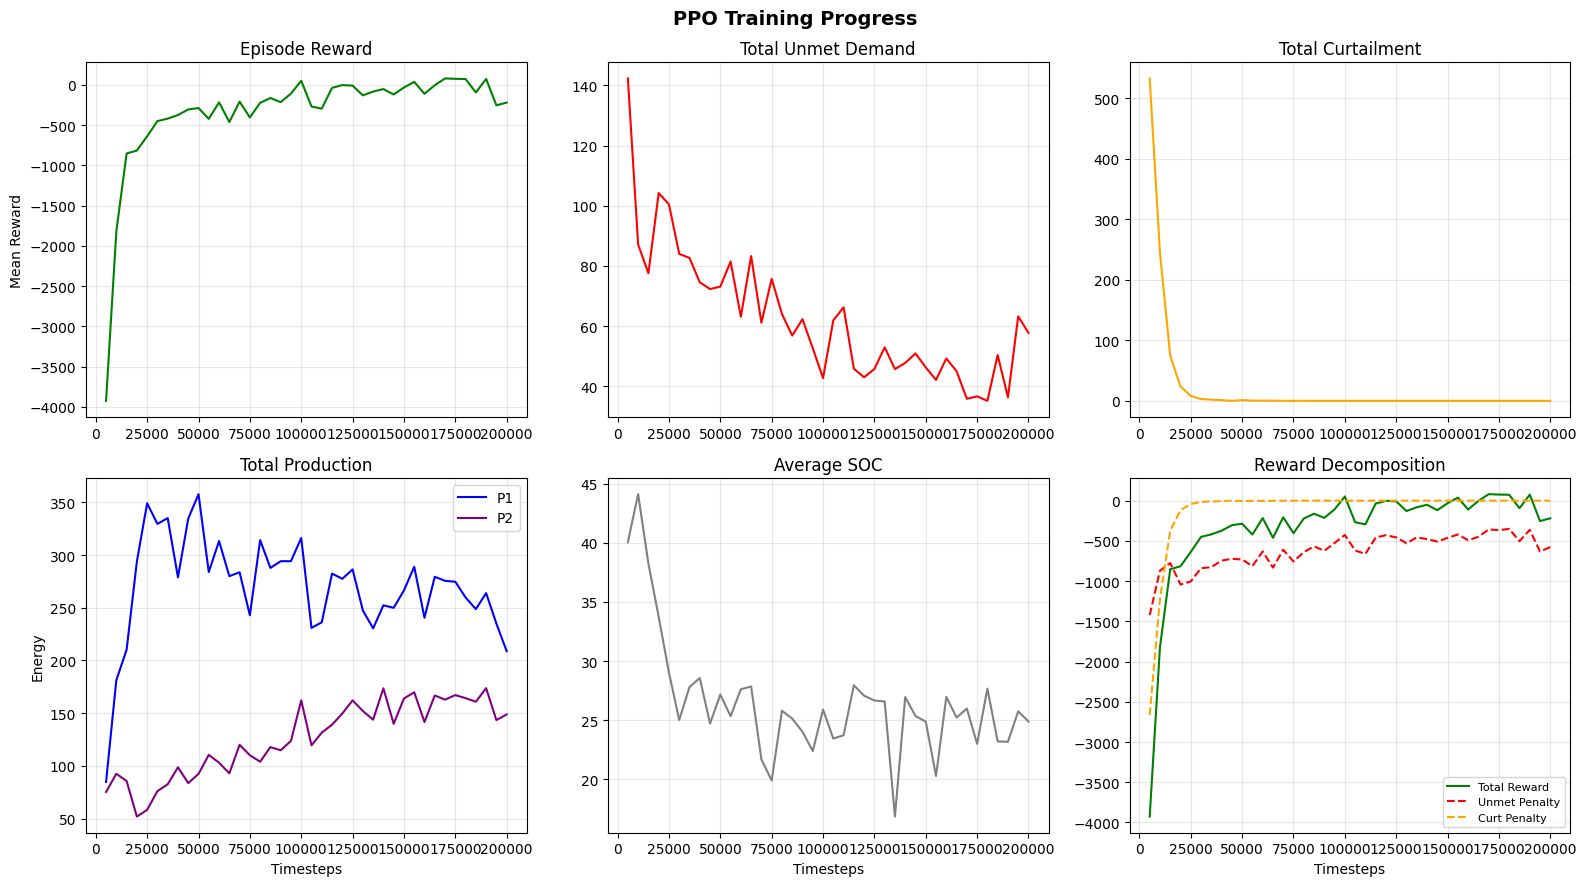

In [30]:
plot_training_progress()

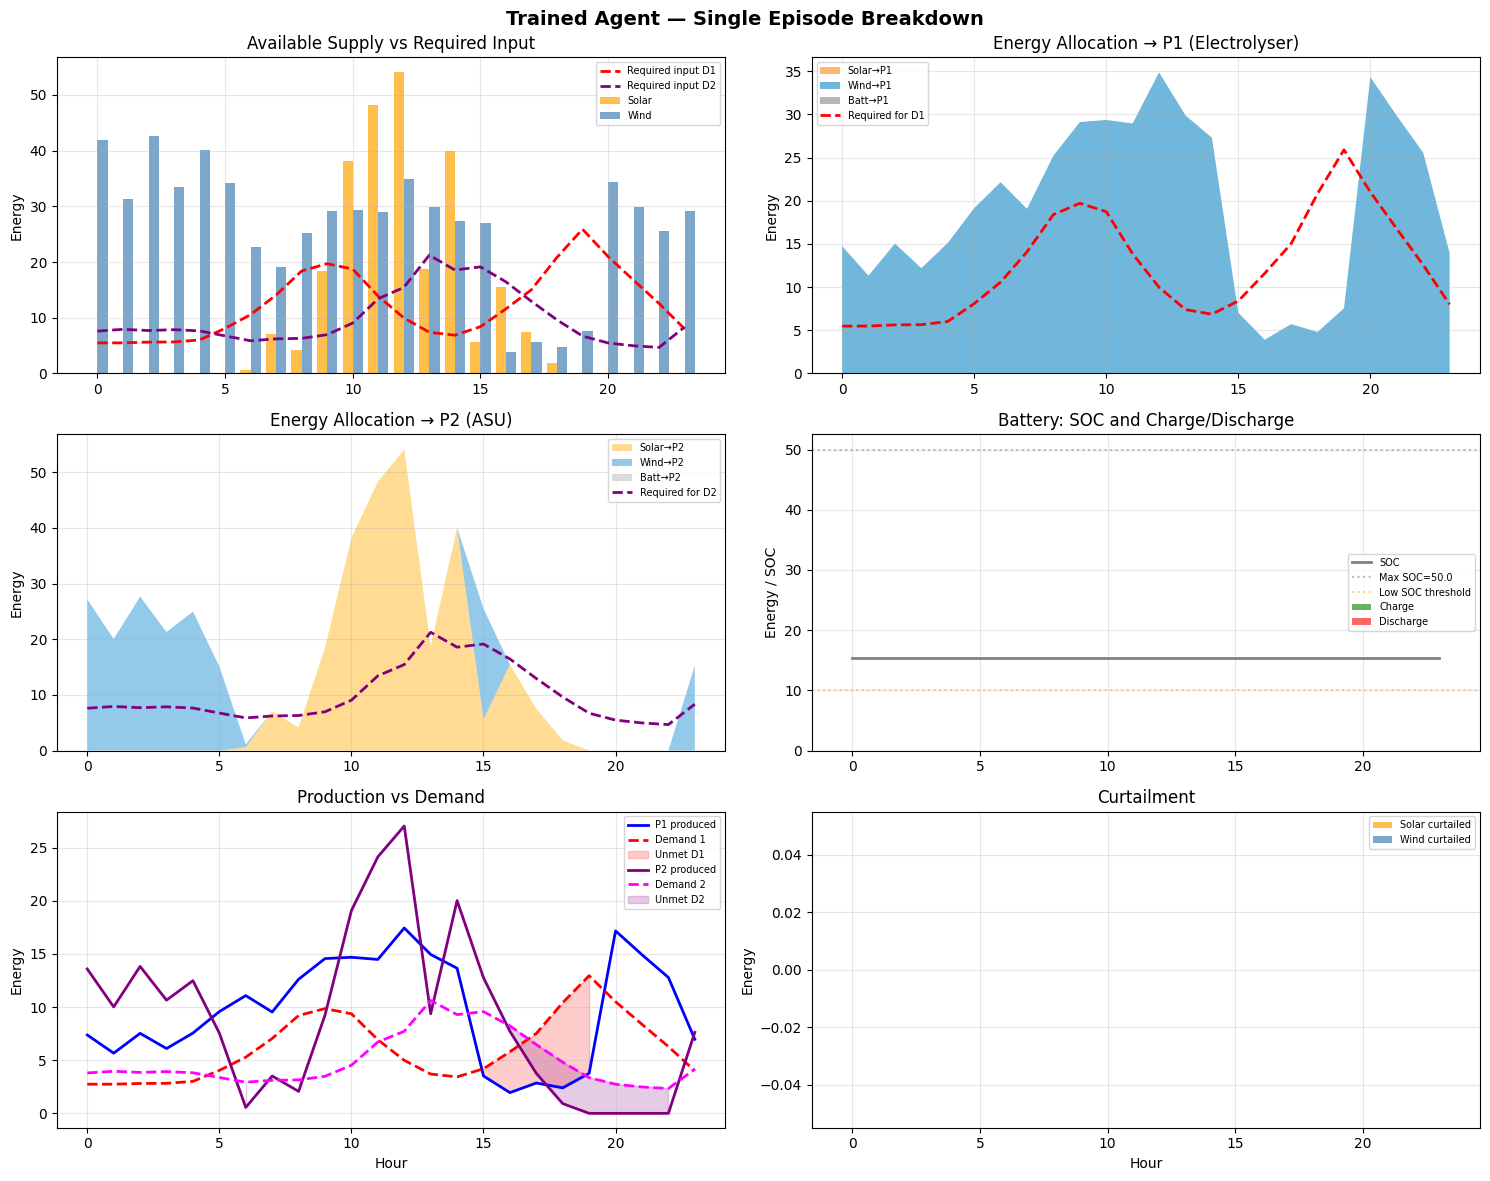

Total P1: 233.1 | Total Demand 1: 148.0 | Unmet 1: 26.4
Total P2: 215.8 | Total Demand 2: 118.4 | Unmet 2: 22.7
Total curtailment: 0.0
Battery cycles: charged 0.0, discharged 0.0
Final SOC: 15.4


In [ ]:
# --- Visualize a single episode hour by hour ---
env = BatteryEnv()
obs, _ = env.reset()

# Collect data for every timestep
episode_data = {
    "solar": [], "wind": [], "demand_1": [], "demand_2": [],
    "E11": [], "E12": [], "E21": [], "E22": [],
    "E1B": [], "E2B": [], "B1": [], "B2": [],
    "P1": [], "P2": [], "soc": [],
    "unmet_1": [], "unmet_2": [],
    "curt_solar": [], "curt_wind": [],
    "actual_charge": [], "actual_discharge": [],
}

done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    for key in episode_data:
        episode_data[key].append(info[key])

# Convert to arrays
for key in episode_data:
    episode_data[key] = np.array(episode_data[key])

hours = np.arange(24)
d = episode_data  # Shorthand

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle("Trained Agent — Single Episode Breakdown", fontsize=14, fontweight="bold")

# --- Supply and Demand ---
ax = axes[0, 0]
ax.bar(hours - 0.2, d["solar"], width=0.4, color="orange", alpha=0.7, label="Solar")
ax.bar(hours + 0.2, d["wind"], width=0.4, color="steelblue", alpha=0.7, label="Wind")
ax.plot(hours, d["demand_1"] / env.a, color="red", linewidth=2, linestyle="--", label="Required input D1")
ax.plot(hours, d["demand_2"] / env.b, color="purple", linewidth=2, linestyle="--", label="Required input D2")
ax.set_title("Available Supply vs Required Input")
ax.set_ylabel("Energy")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# --- Energy Allocation ---
ax = axes[0, 1]
ax.stackplot(hours,
             d["E11"], d["E21"], d["B1"],
             labels=["Solar→P1", "Wind→P1", "Batt→P1"],
             colors=["#ff9933", "#3399cc", "#999999"], alpha=0.7)
ax.plot(hours, d["demand_1"] / env.a, color="red", linewidth=2, linestyle="--", label="Required for D1")
ax.set_title("Energy Allocation → P1 (Electrolyser)")
ax.set_ylabel("Energy")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# --- Energy Allocation P2 ---
ax = axes[1, 0]
ax.stackplot(hours,
             d["E12"], d["E22"], d["B2"],
             labels=["Solar→P2", "Wind→P2", "Batt→P2"],
             colors=["#ffcc66", "#66b3e0", "#cccccc"], alpha=0.7)
ax.plot(hours, d["demand_2"] / env.b, color="purple", linewidth=2, linestyle="--", label="Required for D2")
ax.set_title("Energy Allocation → P2 (ASU)")
ax.set_ylabel("Energy")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# --- Battery ---
ax = axes[1, 1]
ax.plot(hours, d["soc"], color="gray", linewidth=2, label="SOC")
ax.bar(hours - 0.2, d["actual_charge"], width=0.4, color="green", alpha=0.6, label="Charge")
ax.bar(hours + 0.2, -d["actual_discharge"], width=0.4, color="red", alpha=0.6, label="Discharge")
ax.axhline(y=env.max_soc, color="gray", linestyle=":", alpha=0.5, label=f"Max SOC={env.max_soc}")
ax.axhline(y=env.soc_threshold * env.max_soc, color="orange", linestyle=":", alpha=0.5, label="Low SOC threshold")
ax.set_title("Battery: SOC and Charge/Discharge")
ax.set_ylabel("Energy / SOC")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# --- Production vs Demand ---
ax = axes[2, 0]
ax.plot(hours, d["P1"], color="blue", linewidth=2, label="P1 produced")
ax.plot(hours, d["demand_1"], color="red", linewidth=2, linestyle="--", label="Demand 1")
ax.fill_between(hours, d["P1"], d["demand_1"],
                where=d["P1"] < d["demand_1"], color="red", alpha=0.2, label="Unmet D1")
ax.plot(hours, d["P2"], color="purple", linewidth=2, label="P2 produced")
ax.plot(hours, d["demand_2"], color="magenta", linewidth=2, linestyle="--", label="Demand 2")
ax.fill_between(hours, d["P2"], d["demand_2"],
                where=d["P2"] < d["demand_2"], color="purple", alpha=0.2, label="Unmet D2")
ax.set_title("Production vs Demand")
ax.set_xlabel("Hour")
ax.set_ylabel("Energy")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# --- Curtailment ---
ax = axes[2, 1]
ax.bar(hours - 0.2, d["curt_solar"], width=0.4, color="orange", alpha=0.7, label="Solar curtailed")
ax.bar(hours + 0.2, d["curt_wind"], width=0.4, color="steelblue", alpha=0.7, label="Wind curtailed")
ax.set_title("Curtailment")
ax.set_xlabel("Hour")
ax.set_ylabel("Energy")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Print episode summary ---
print(f"Total P1: {d['P1'].sum():.1f} | Total Demand 1: {d['demand_1'].sum():.1f} | Unmet 1: {d['unmet_1'].sum():.1f}")
print(f"Total P2: {d['P2'].sum():.1f} | Total Demand 2: {d['demand_2'].sum():.1f} | Unmet 2: {d['unmet_2'].sum():.1f}")
print(f"Total curtailment: {(d['curt_solar'] + d['curt_wind']).sum():.1f}")
print(f"Battery cycles: charged {d['actual_charge'].sum():.1f}, discharged {d['actual_discharge'].sum():.1f}")
print(f"Final SOC: {d['soc'][-1]:.1f}")